In [1]:
import sys
sys.path.append('/blue/adamginsburg/t.yoo/SPICY_ALMAIMF')
import imp, table_loading
imp.reload(table_loading)
from table_loading import fit_a_source, geometries
from astropy.table import Table
from plot_fit import plot_fit, datafunction
import numpy as np
from astropy import constants
from astropy import units as u
from astropy.modeling import models, fitting



/tmp/ipykernel_2479752/2700754891.py:3: DeprecationWarning: the imp module is deprecated in favour of importlib and slated for removal in Python 3.12; see the module's documentation for alternative uses
  import imp, table_loading


In [2]:
from photutils.aperture import SkyCircularAperture
from photutils.aperture import aperture_photometry
from photutils.aperture import SkyCircularAnnulus
from photutils.aperture import ApertureStats
from astropy.wcs import WCS
from astropy.io import fits
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.table import Table
#from filtering import get_filtername, get_fwhm
import plot_fit
from astroquery.svo_fps import SvoFps
from dust_extinction.averages import RL85_MWGC, CT06_MWLoc
import plot_fit
imp.reload(plot_fit)
from plot_fit import plot_fit, datafunction
from scipy.ndimage import binary_dilation
from matplotlib.lines import Line2D



catalog = Table.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/final_catalog_new.fits')
nmatch = catalog['nmatch_bands']
catalog = catalog[nmatch>3]

image_filenames ={
    "f140m": "/orange/adamginsburg/jwst/w51/F140M/pipeline/jw06151-o001_t001_nircam_clear-f140m-merged_i2d.fits",
    "f162m": "/orange/adamginsburg/jwst/w51/F162M/pipeline/jw06151-o001_t001_nircam_clear-f162m-merged_i2d.fits",
    "f182m": "/orange/adamginsburg/jwst/w51/F182M/pipeline/jw06151-o001_t001_nircam_clear-f182m-merged_i2d.fits",
    "f187n": "/orange/adamginsburg/jwst/w51/F187N/pipeline/jw06151-o001_t001_nircam_clear-f187n-merged_i2d.fits",
    "f210m": "/orange/adamginsburg/jwst/w51/F210M/pipeline/jw06151-o001_t001_nircam_clear-f210m-merged_i2d.fits",
    "f335m": "/orange/adamginsburg/jwst/w51/F335M/pipeline/jw06151-o001_t001_nircam_clear-f335m-merged_i2d.fits",
    "f360m": "/orange/adamginsburg/jwst/w51/F360M/pipeline/jw06151-o001_t001_nircam_clear-f360m-merged_i2d.fits",
    "f405n": "/orange/adamginsburg/jwst/w51/F405N/pipeline/jw06151-o001_t001_nircam_clear-f405n-merged_i2d.fits",
    "f410m": "/orange/adamginsburg/jwst/w51/F410M/pipeline/jw06151-o001_t001_nircam_clear-f410m-merged_i2d.fits", # weird, the filename is different from what is downloaded with the STScI pipeline...
    "f480m": "/orange/adamginsburg/jwst/w51/F480M/pipeline/jw06151-o001_t001_nircam_clear-f480m-merged_i2d.fits",
    "f560w": "/orange/adamginsburg/jwst/w51/F560W/pipeline/jw06151-o002_t001_miri_f560w_i2d.fits",
    "f770w": "/orange/adamginsburg/jwst/w51/F770W/pipeline/jw06151-o002_t001_miri_f770w_i2d.fits",
    "f1000w": "/orange/adamginsburg/jwst/w51/F1000W/pipeline/jw06151-o002_t001_miri_f1000w_i2d.fits",
    "f1280w": "/orange/adamginsburg/jwst/w51/F1280W/pipeline/jw06151-o002_t001_miri_f1280w_i2d.fits",
    "f2100w": "/orange/adamginsburg/jwst/w51/F2100W/pipeline/jw06151-o002_t001_miri_f2100w_i2d.fits",
    
}


f140m_header = fits.getheader(image_filenames['f140m'], ext=('SCI', 1))
f162m_header = fits.getheader(image_filenames['f162m'], ext=('SCI', 1))
f182m_header = fits.getheader(image_filenames['f182m'], ext=('SCI', 1))
f210m_header = fits.getheader(image_filenames['f210m'], ext=('SCI', 1))
f335m_header = fits.getheader(image_filenames['f335m'], ext=('SCI', 1))
f360m_header = fits.getheader(image_filenames['f360m'], ext=('SCI', 1))
f405n_header = fits.getheader(image_filenames['f405n'], ext=('SCI', 1))
f410m_header = fits.getheader(image_filenames['f410m'], ext=('SCI', 1))
f480m_header = fits.getheader(image_filenames['f480m'], ext=('SCI', 1))
f560w_header = fits.getheader(image_filenames['f560w'], ext=('SCI', 1))
f770w_header = fits.getheader(image_filenames['f770w'], ext=('SCI', 1))
f1000w_header = fits.getheader(image_filenames['f1000w'], ext=('SCI', 1))
f1280w_header = fits.getheader(image_filenames['f1280w'], ext=('SCI', 1))
f2100w_header = fits.getheader(image_filenames['f2100w'], ext=('SCI', 1))

def get_mag(catalog, ww, filtername='f140m' ):
    print(ww.proj_plane_pixel_area())
    
    flux= (catalog['flux_fit_' + filtername] * u.MJy/u.sr * ww.proj_plane_pixel_area()).to(u.Jy)
    eflux_jy = (catalog['flux_err_' + filtername] * u.MJy/u.sr *  ww.proj_plane_pixel_area()).to(u.Jy)

    jfilts = SvoFps.get_filter_list('JWST')
    jfilts.add_index('filterID')
    wav = int(filtername[1:-1])

    zeropoint_ab = 3631 * u.Jy  # Default to AB magnitude zero point
 
    if wav < 500:

        zeropoint_vega = u.Quantity(jfilts.loc[f'JWST/NIRCam.{filtername.upper()}']['ZeroPoint'], u.Jy)
    else:
        zeropoint_vega = u.Quantity(jfilts.loc[f'JWST/MIRI.{filtername.upper()}']['ZeroPoint'], u.Jy)
   
    abmag = -2.5 * np.log10(flux / zeropoint_ab) * u.mag
    abmag_err = 2.5 / np.log(10) * np.abs(eflux_jy / flux) * u.mag

    vegamag = -2.5 * np.log10(flux / zeropoint_vega) * u.mag
    vegamag_err = 2.5 / np.log(10) * np.abs(eflux_jy / flux) * u.mag

    return  vegamag, vegamag_err, abmag, abmag_err

f140m_mag = get_mag(catalog, WCS(f140m_header), filtername='f140m')
f162m_mag = get_mag(catalog, WCS(f162m_header), filtername='f162m')
f182m_mag = get_mag(catalog, WCS(f182m_header), filtername='f182m')
f210m_mag = get_mag(catalog, WCS(f210m_header), filtername='f210m')
f335m_mag = get_mag(catalog, WCS(f335m_header), filtername='f335m')
f360m_mag = get_mag(catalog, WCS(f360m_header), filtername='f360m')
f405n_mag = get_mag(catalog, WCS(f405n_header), filtername='f405n')
f410m_mag = get_mag(catalog, WCS(f410m_header), filtername='f410m')
f480m_mag = get_mag(catalog, WCS(f480m_header), filtername='f480m')
f560w_mag = get_mag(catalog, WCS(f560w_header), filtername='f560w')
f770w_mag = get_mag(catalog, WCS(f770w_header), filtername='f770w')
f1000w_mag = get_mag(catalog, WCS(f1000w_header), filtername='f1000w')
f1280w_mag = get_mag(catalog, WCS(f1280w_header), filtername='f1280w')
f2100w_mag = get_mag(catalog, WCS(f2100w_header), filtername='f2100w')

f187n_header = fits.getheader(image_filenames['f187n'], ext=('SCI', 1))
f187n_mag = get_mag(catalog, WCS(f187n_header), filtername='f187n')

f162 = f162m_mag[0].to_value(u.mag)
f210 = f210m_mag[0].to_value(u.mag)
f360 = f360m_mag[0].to_value(u.mag)
f480 = f480m_mag[0].to_value(u.mag)

num_sources = len(catalog)

from dust_extinction.averages import RL85_MWGC, CT06_MWGC
from dust_extinction.parameter_averages import CCM89
import astropy.constants as const

ext = CT06_MWLoc()

mags = {
    'f140m': f140m_mag,
    'f162m': f162m_mag,
    'f182m': f182m_mag,
   # 'f187n': f187n_mag,
    'f210m': f210m_mag,
    'f335m': f335m_mag,
    'f360m': f360m_mag,
    #'f405n': f405n_mag,
    'f410m': f410m_mag,
    'f480m': f480m_mag,
    'f560w': f560w_mag,
    'f770w': f770w_mag,
    'f1000w': f1000w_mag,
    'f1280w': f1280w_mag,
    'f2100w': f2100w_mag,
}


def get_av(color, mag, ext=CT06_MWLoc(), color1=('f140m', 'f162m'), mag1=('f140m',), isochrone_line_params=None):
    # Get the slope and intercept of the isochrone line
    m_iso, b_iso = isochrone_line_params
    print('color1:', color1, 'mag1:', mag1)

    # Get the extinction vector components
    w_color1_1 = int(color1[0][1:-1])/100*u.um
    w_color1_2 = int(color1[1][1:-1])/100*u.um
    w_mag1 = int(mag1[0][1:-1])/100*u.um
    print('w_color1_1:', w_color1_1, 'w_color1_2:', w_color1_2, 'w_mag1:', w_mag1)

    e_color1_1 = ext(1/w_color1_1)
    e_color1_2 = ext(1/w_color1_2)
    e_mag1 = ext(1/w_mag1)

    # get the contact to the isochrone line along the extinction vector
    # the extinction vector can be represented as a line with slope m_ext = e_mag1 / (e_color1_1 - e_color1_2) and passing through the point (color, mag)
    m_ext = e_mag1 / (e_color1_1 - e_color1_2)
    b_ext = mag - m_ext * color

    # find the intersection of the isochrone line and the extinction vector
    x_int = (b_ext - b_iso) / (m_iso - m_ext)
    y_int = m_iso * x_int + b_iso

    # calculate A_V as the distance from (color, mag) to (x_int, y_int) along the extinction vector
    av = (mag - y_int) / ext(1/w_mag1)
    av[av < 0] = 0
    return av
parsec_av0 = Table.read('/home/t.yoo/parsec_av0.txt', format='ascii')
parsec_av0.pprint(max_width=-1, max_lines=-1)   
m_init = parsec_av0['col4']  
parsec_av0 = parsec_av0[m_init<300]              
logage_av0 = parsec_av0['col3']
mass_av0 = parsec_av0['col6']
print(np.min(m_init), np.max(m_init))
print(np.min(mass_av0), np.max(mass_av0))
F140Mmag_av0 = parsec_av0['col39'] + 5*np.log10(5400)-5
F162Mmag_av0 = parsec_av0['col40']+ 5*np.log10(5400)-5
F182Mmag_av0 = parsec_av0['col41']+ 5*np.log10(5400)-5
F210Mmag_av0 = parsec_av0['col42']+ 5*np.log10(5400)-5
F335Mmag_av0 = parsec_av0['col45']+ 5*np.log10(5400)-5
F360Mmag_av0 = parsec_av0['col46']+ 5*np.log10(5400)-5
F410Mmag_av0 = parsec_av0['col47']+ 5*np.log10(5400)-5
F480Mmag_av0 = parsec_av0['col50']+ 5*np.log10(5400)-5
age_idx = logage_av0 == 6
idx_01msun = np.argmin(np.abs(mass_av0[age_idx]-0.1))
idx_20msun = np.argmin(np.abs(mass_av0[age_idx]-20))
isochrone_x_start = F162Mmag_av0[age_idx][idx_01msun] - F210Mmag_av0[age_idx][idx_01msun]
isochrone_x_end = F162Mmag_av0[age_idx][idx_20msun] - F210Mmag_av0[age_idx][idx_20msun]
isocrhone_y_start = F162Mmag_av0[age_idx][idx_01msun]
isocrhone_y_end = F162Mmag_av0[age_idx][idx_20msun]
color_slope = (isocrhone_y_end - isocrhone_y_start) / (isochrone_x_end - isochrone_x_start)
color_intercept = isocrhone_y_start - color_slope * isochrone_x_start
av_estimates = get_av(color=f162-f210, mag=f162, ext=CT06_MWLoc(), color1=('f162m', 'f210m'), mag1=('f162m',), isochrone_line_params=(color_slope, color_intercept))





7.525093724479512e-11 deg2
7.52790883669383e-11 deg2
7.52510476872822e-11 deg2
7.52514718037244e-11 deg2
3.053877779107583e-10 deg2
3.0536898714608487e-10 deg2
3.056563930691893e-10 deg2
3.0541063885182936e-10 deg2
3.054668262896466e-10 deg2
9.491459138193236e-10 deg2
9.491652259572426e-10 deg2
9.491458943030916e-10 deg2
9.491652069110604e-10 deg2
9.491651972183757e-10 deg2
7.524574264515582e-11 deg2
 col1    col2  col3      col4          col5       col6   col7   col8   col9  col10 col11 col12   col13  col14  col15  col16  col17  col18   col19   col20   col21   col22    col23     col24     col25   col26   col27   col28   col29   col30   col31   col32   col33   col34   col35   col36   col37   col38   col39   col40   col41   col42   col43   col44   col45   col46   col47   col48   col49   col50 
------ ------- ---- -------------- ------------ ------- ------ ------ ------ ----- ----- ------ ------- ------ ------ ------ ------ ----- --------- ----- --------- ------ --------- --------- -----

filt: f140m, flux_fit: 99.27643697933546, flux_err: 1.0303285297639149
filt: f162m, flux_fit: 311.06336092076623, flux_err: 1.9814109976730527
filt: f182m, flux_fit: 620.0376278781201, flux_err: 2.8153499690692554
filt: f210m, flux_fit: 1172.3980807987286, flux_err: 4.715109498129878
filt: f335m, flux_fit: 1113.054650178651, flux_err: 6.554837711891495
filt: f360m, flux_fit: 1325.9766973722428, flux_err: 7.126085908408132
filt: f410m, flux_fit: 1561.3871926720421, flux_err: 9.660651600934282
filt: f480m, flux_fit: 1825.1876832666946, flux_err: 6.983258289967914
filt: f560w, flux_fit: 553.8516259009032, flux_err: 8.103920316980275
filt: f770w, flux_fit: --, flux_err: --
filt: f1000w, flux_fit: 240.13449274290124, flux_err: 6.054529577951152
filt: f1280w, flux_fit: --, flux_err: --
filt: f2100w, flux_fit: --, flux_err: --
skycoord: <SkyCoord (ICRS): (ra, dec) in deg
    (290.90608579, 14.52552942)>
flux is not masked for flux_fit_f140m
flux is not masked for flux_fit_f162m
flux is not ma

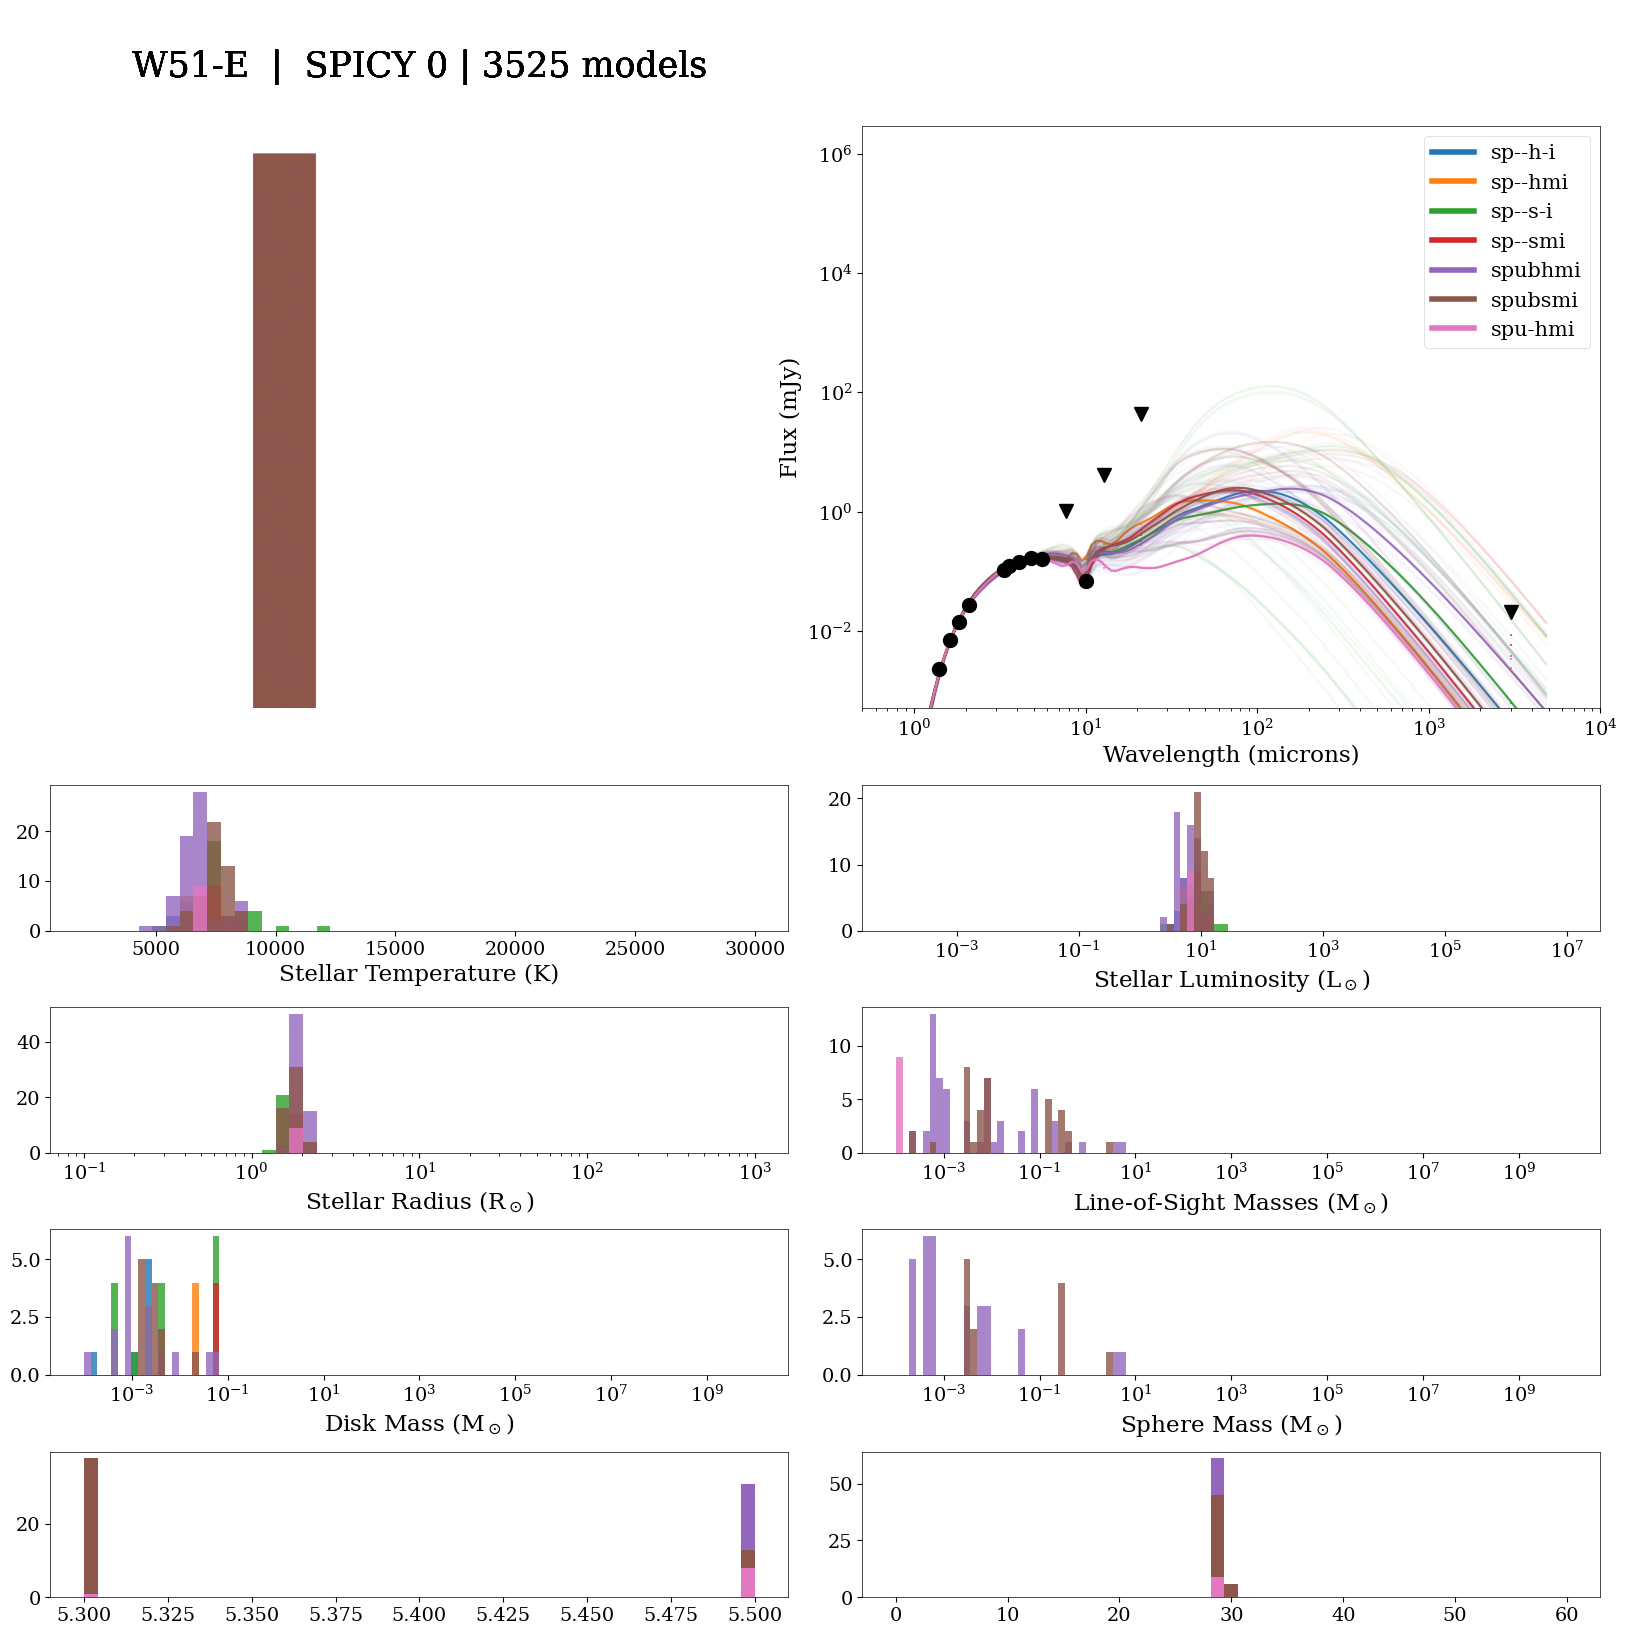

filt: f140m, flux_fit: 7.837764196346362, flux_err: 0.5089920730419394
filt: f162m, flux_fit: 85.42743354671467, flux_err: 1.7923711180012012
filt: f182m, flux_fit: 305.6737663552607, flux_err: 4.043334726135645
filt: f210m, flux_fit: 848.9588675442144, flux_err: 8.643429047929377
filt: f335m, flux_fit: 891.1368337205587, flux_err: 8.799119477130105
filt: f360m, flux_fit: 1343.02356845276, flux_err: 11.779952375417778
filt: f410m, flux_fit: 1716.956434665801, flux_err: 22.45648932878504
filt: f480m, flux_fit: 2026.0651349464788, flux_err: 11.4105248227926
filt: f560w, flux_fit: 542.8467345686773, flux_err: 27.136913782248584
filt: f770w, flux_fit: --, flux_err: --
filt: f1000w, flux_fit: --, flux_err: --
filt: f1280w, flux_fit: --, flux_err: --
filt: f2100w, flux_fit: --, flux_err: --
skycoord: <SkyCoord (ICRS): (ra, dec) in deg
    (290.93677776, 14.52064422)>
flux is not masked for flux_fit_f140m
flux is not masked for flux_fit_f162m
flux is not masked for flux_fit_f182m
flux is not 

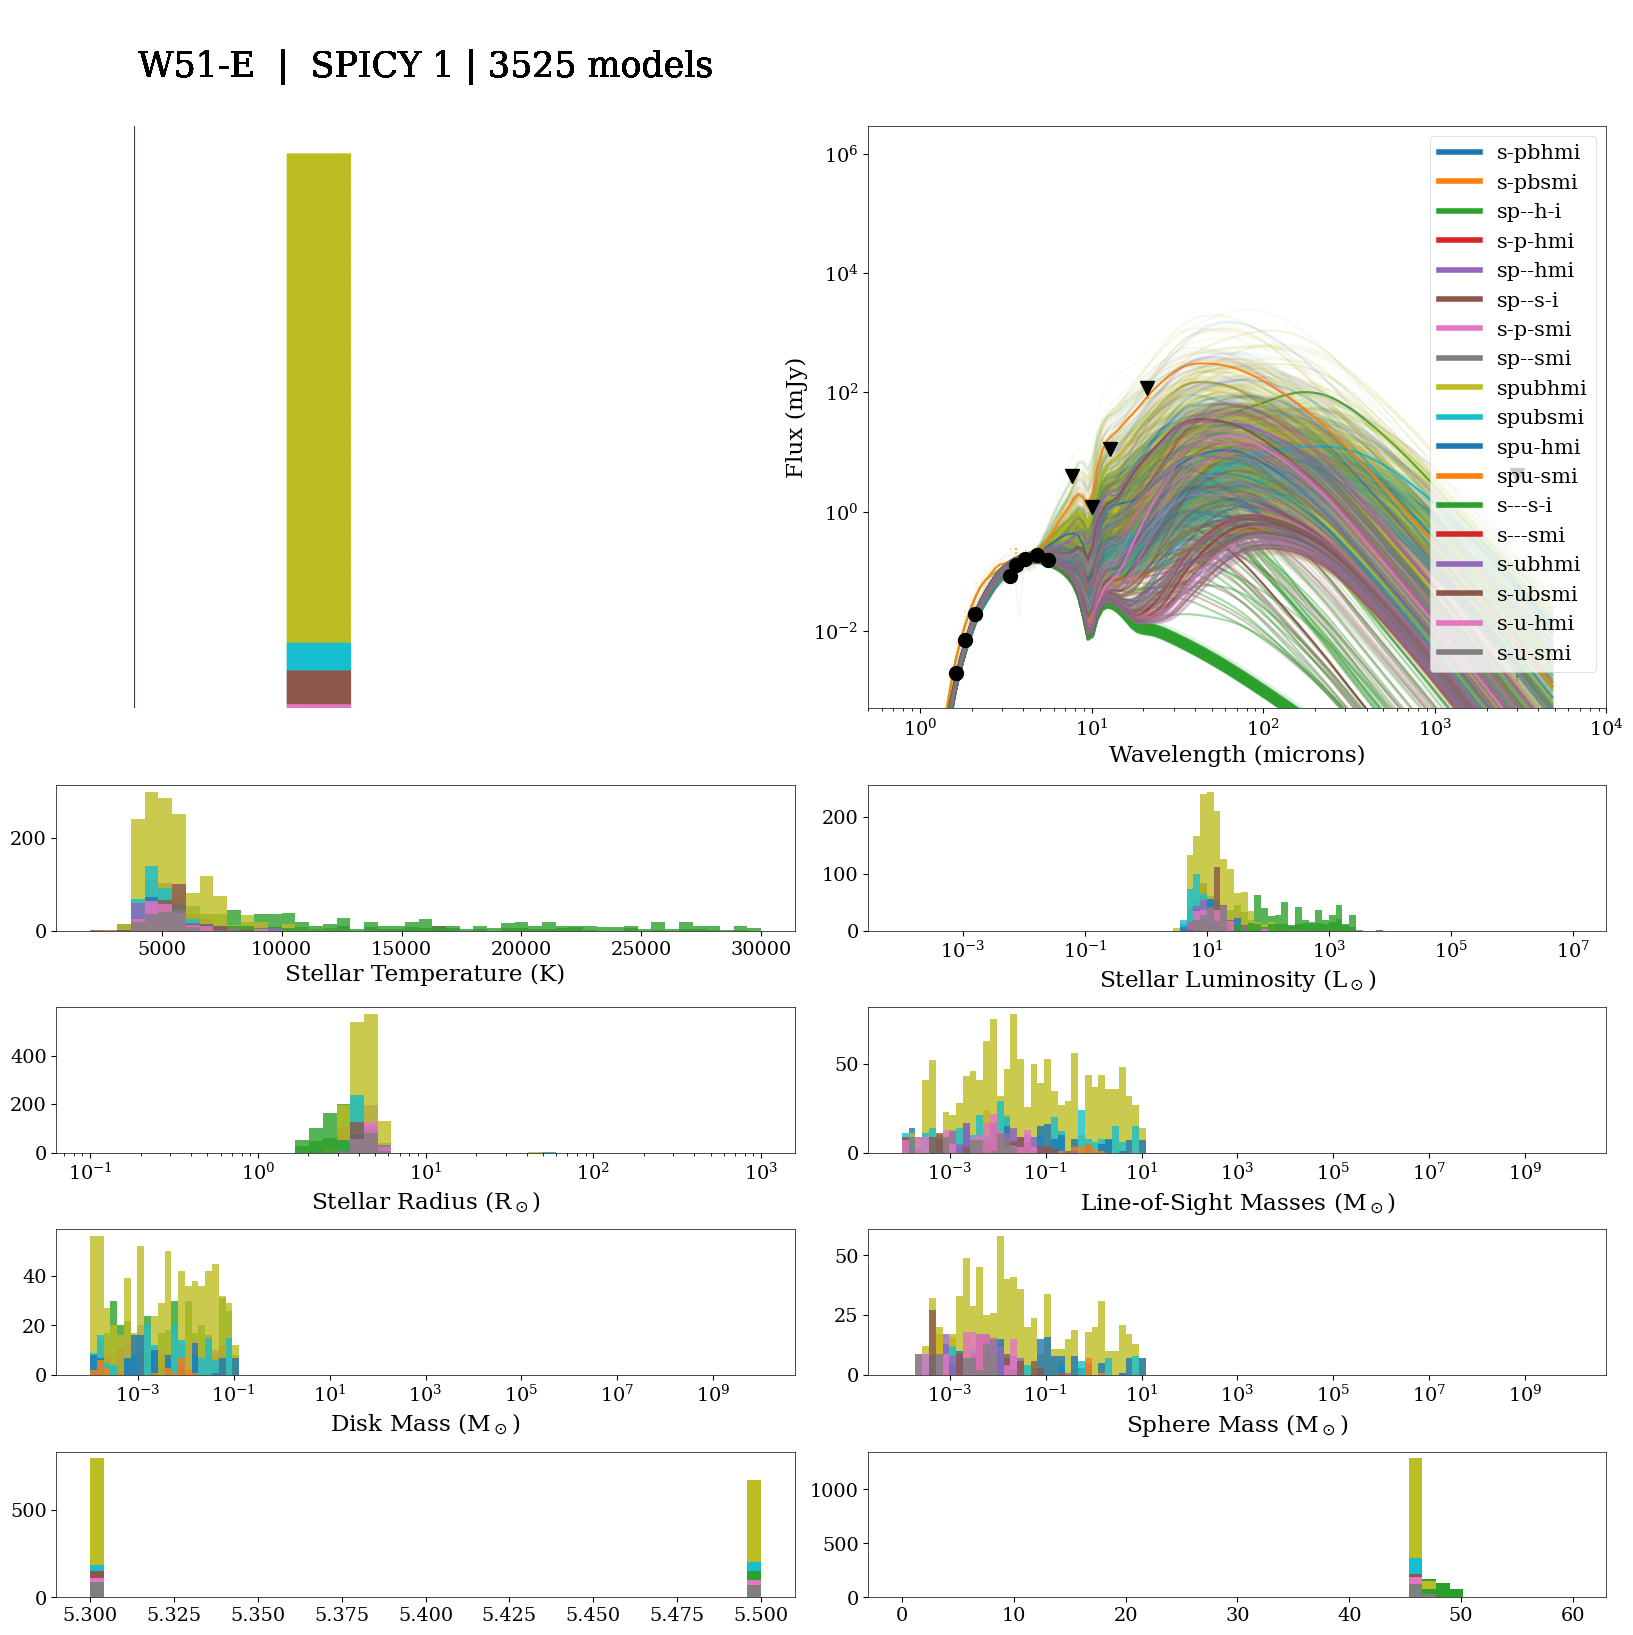

filt: f140m, flux_fit: 6.800014884098496, flux_err: 0.7577827647161982
filt: f162m, flux_fit: 53.72782583825397, flux_err: 5.852370331268865
filt: f182m, flux_fit: 164.05363896558848, flux_err: 21.036619747385
filt: f210m, flux_fit: 359.03328248504425, flux_err: 51.1291481633
filt: f335m, flux_fit: 566.8054549779043, flux_err: 58.67806836493903
filt: f360m, flux_fit: 706.6692610689537, flux_err: 55.17618462451563
filt: f410m, flux_fit: 931.6594598406002, flux_err: 76.48934529955184
filt: f480m, flux_fit: 1180.3254813535286, flux_err: 65.22836895815655
filt: f560w, flux_fit: 664.5234614846845, flux_err: 85.44708343717663
filt: f770w, flux_fit: 3558.068670225896, flux_err: 511.7064821100809
filt: f1000w, flux_fit: --, flux_err: --
filt: f1280w, flux_fit: --, flux_err: --
filt: f2100w, flux_fit: --, flux_err: --
skycoord: <SkyCoord (ICRS): (ra, dec) in deg
    (290.93406221, 14.51502069)>
flux is not masked for flux_fit_f140m
flux is not masked for flux_fit_f162m
flux is not masked for fl

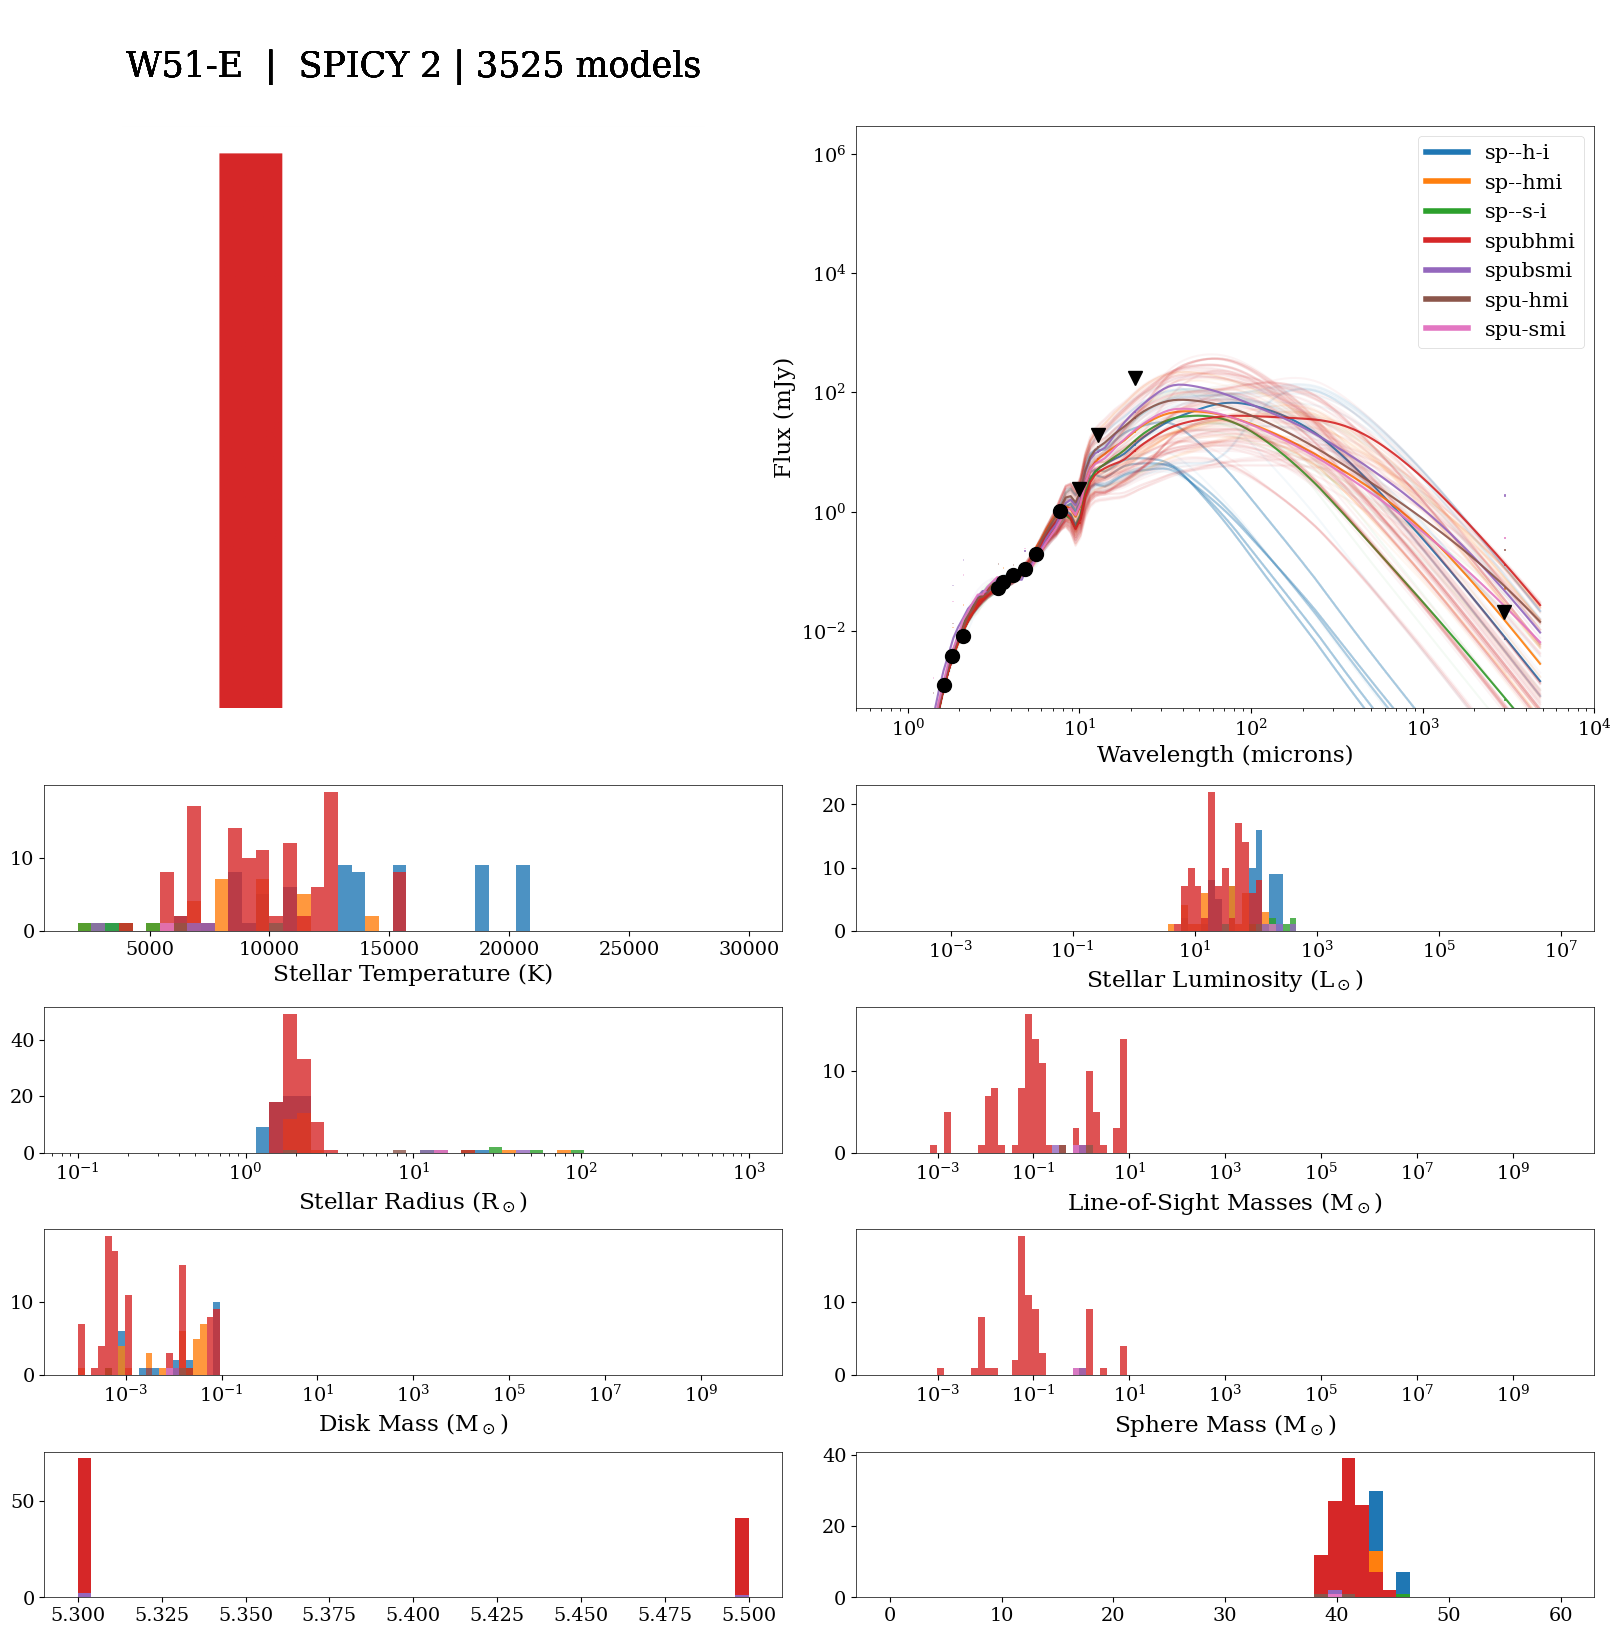

filt: f140m, flux_fit: 8713.851377273386, flux_err: 88.62296381832148
filt: f162m, flux_fit: 25742.48605409505, flux_err: 182.86784405883526
filt: f182m, flux_fit: 46432.7954044258, flux_err: 215.72598947245277
filt: f210m, flux_fit: 69251.50679934869, flux_err: 216.85858515442638
filt: f335m, flux_fit: 21293.641693539874, flux_err: 313.13978766228195
filt: f360m, flux_fit: 23440.10907356842, flux_err: 492.3641941784592
filt: f410m, flux_fit: 25203.805134751965, flux_err: 735.446518818151
filt: f480m, flux_fit: 27269.599640395994, flux_err: 1146.8135000350537
filt: f560w, flux_fit: 15442.988947471662, flux_err: 2729.952589844801
filt: f770w, flux_fit: --, flux_err: --
filt: f1000w, flux_fit: --, flux_err: --
filt: f1280w, flux_fit: --, flux_err: --
filt: f2100w, flux_fit: --, flux_err: --
skycoord: <SkyCoord (ICRS): (ra, dec) in deg
    (290.92050194, 14.51850758)>
flux is not masked for flux_fit_f140m
flux is not masked for flux_fit_f162m
flux is not masked for flux_fit_f182m
flux is 

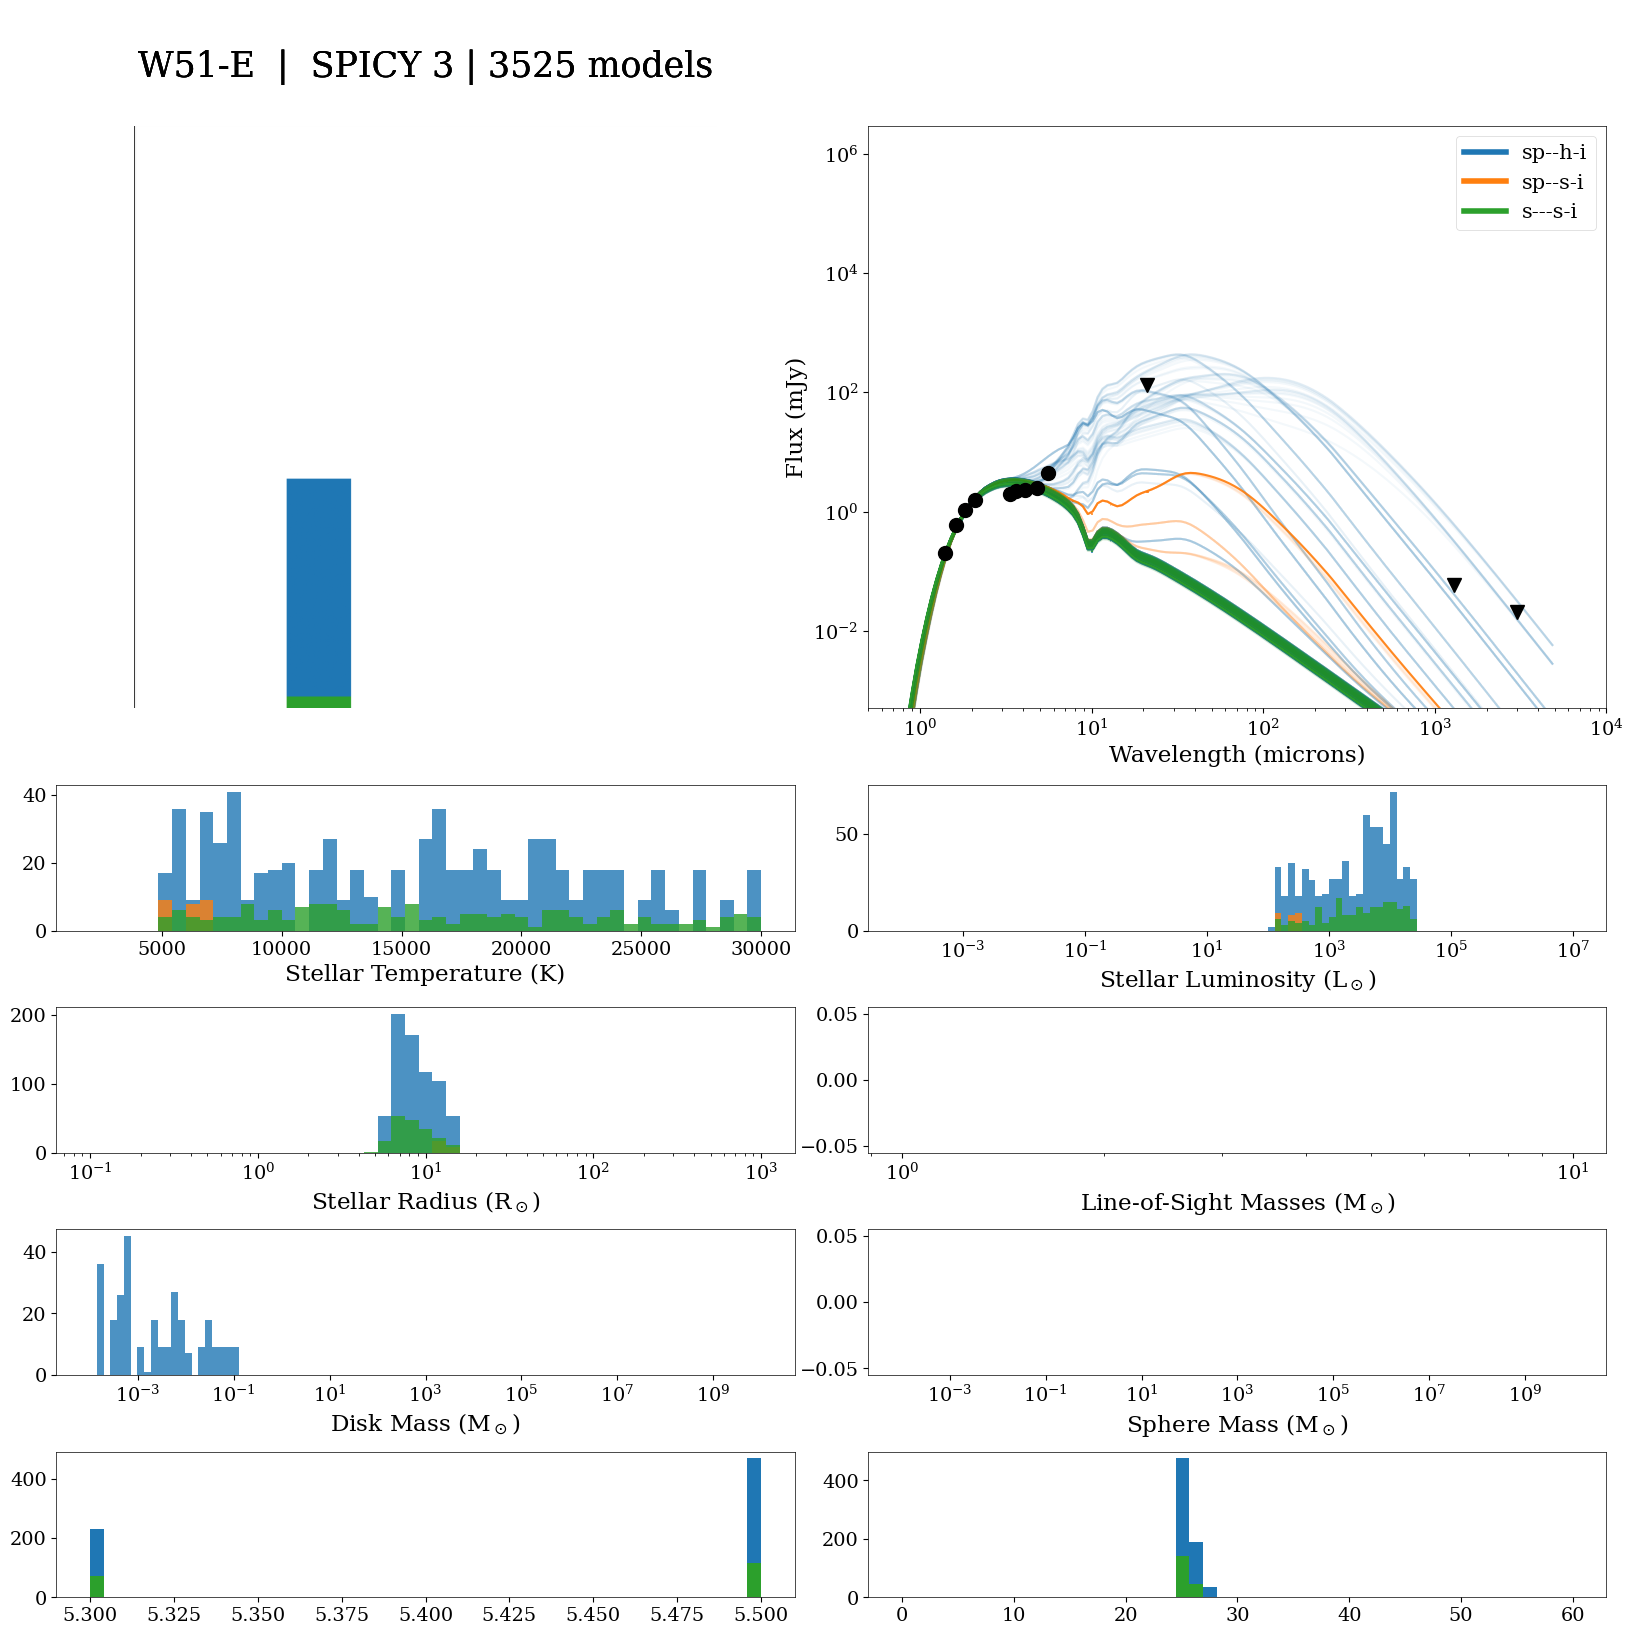

filt: f140m, flux_fit: 270.04271667426605, flux_err: 2.791162490448082
filt: f162m, flux_fit: 1417.442006098421, flux_err: 13.221575983196415
filt: f182m, flux_fit: 3365.442830851152, flux_err: 27.476732791271434
filt: f210m, flux_fit: 6617.665758865563, flux_err: 42.762078995010626
filt: f335m, flux_fit: 4023.134807105852, flux_err: 21.763601667604934
filt: f360m, flux_fit: 5158.133789103685, flux_err: 27.954461010955384
filt: f410m, flux_fit: 5976.835585732988, flux_err: 35.33030831785927
filt: f480m, flux_fit: 6957.244114892489, flux_err: 83.27317399303756
filt: f560w, flux_fit: 1950.3641730338268, flux_err: 38.322408357632014
filt: f770w, flux_fit: 1533.1556263503164, flux_err: 177.65282454532053
filt: f1000w, flux_fit: --, flux_err: --
filt: f1280w, flux_fit: --, flux_err: --
filt: f2100w, flux_fit: --, flux_err: --
skycoord: <SkyCoord (ICRS): (ra, dec) in deg
    (290.91908291, 14.51448345)>
flux is not masked for flux_fit_f140m
flux is not masked for flux_fit_f162m
flux is not m

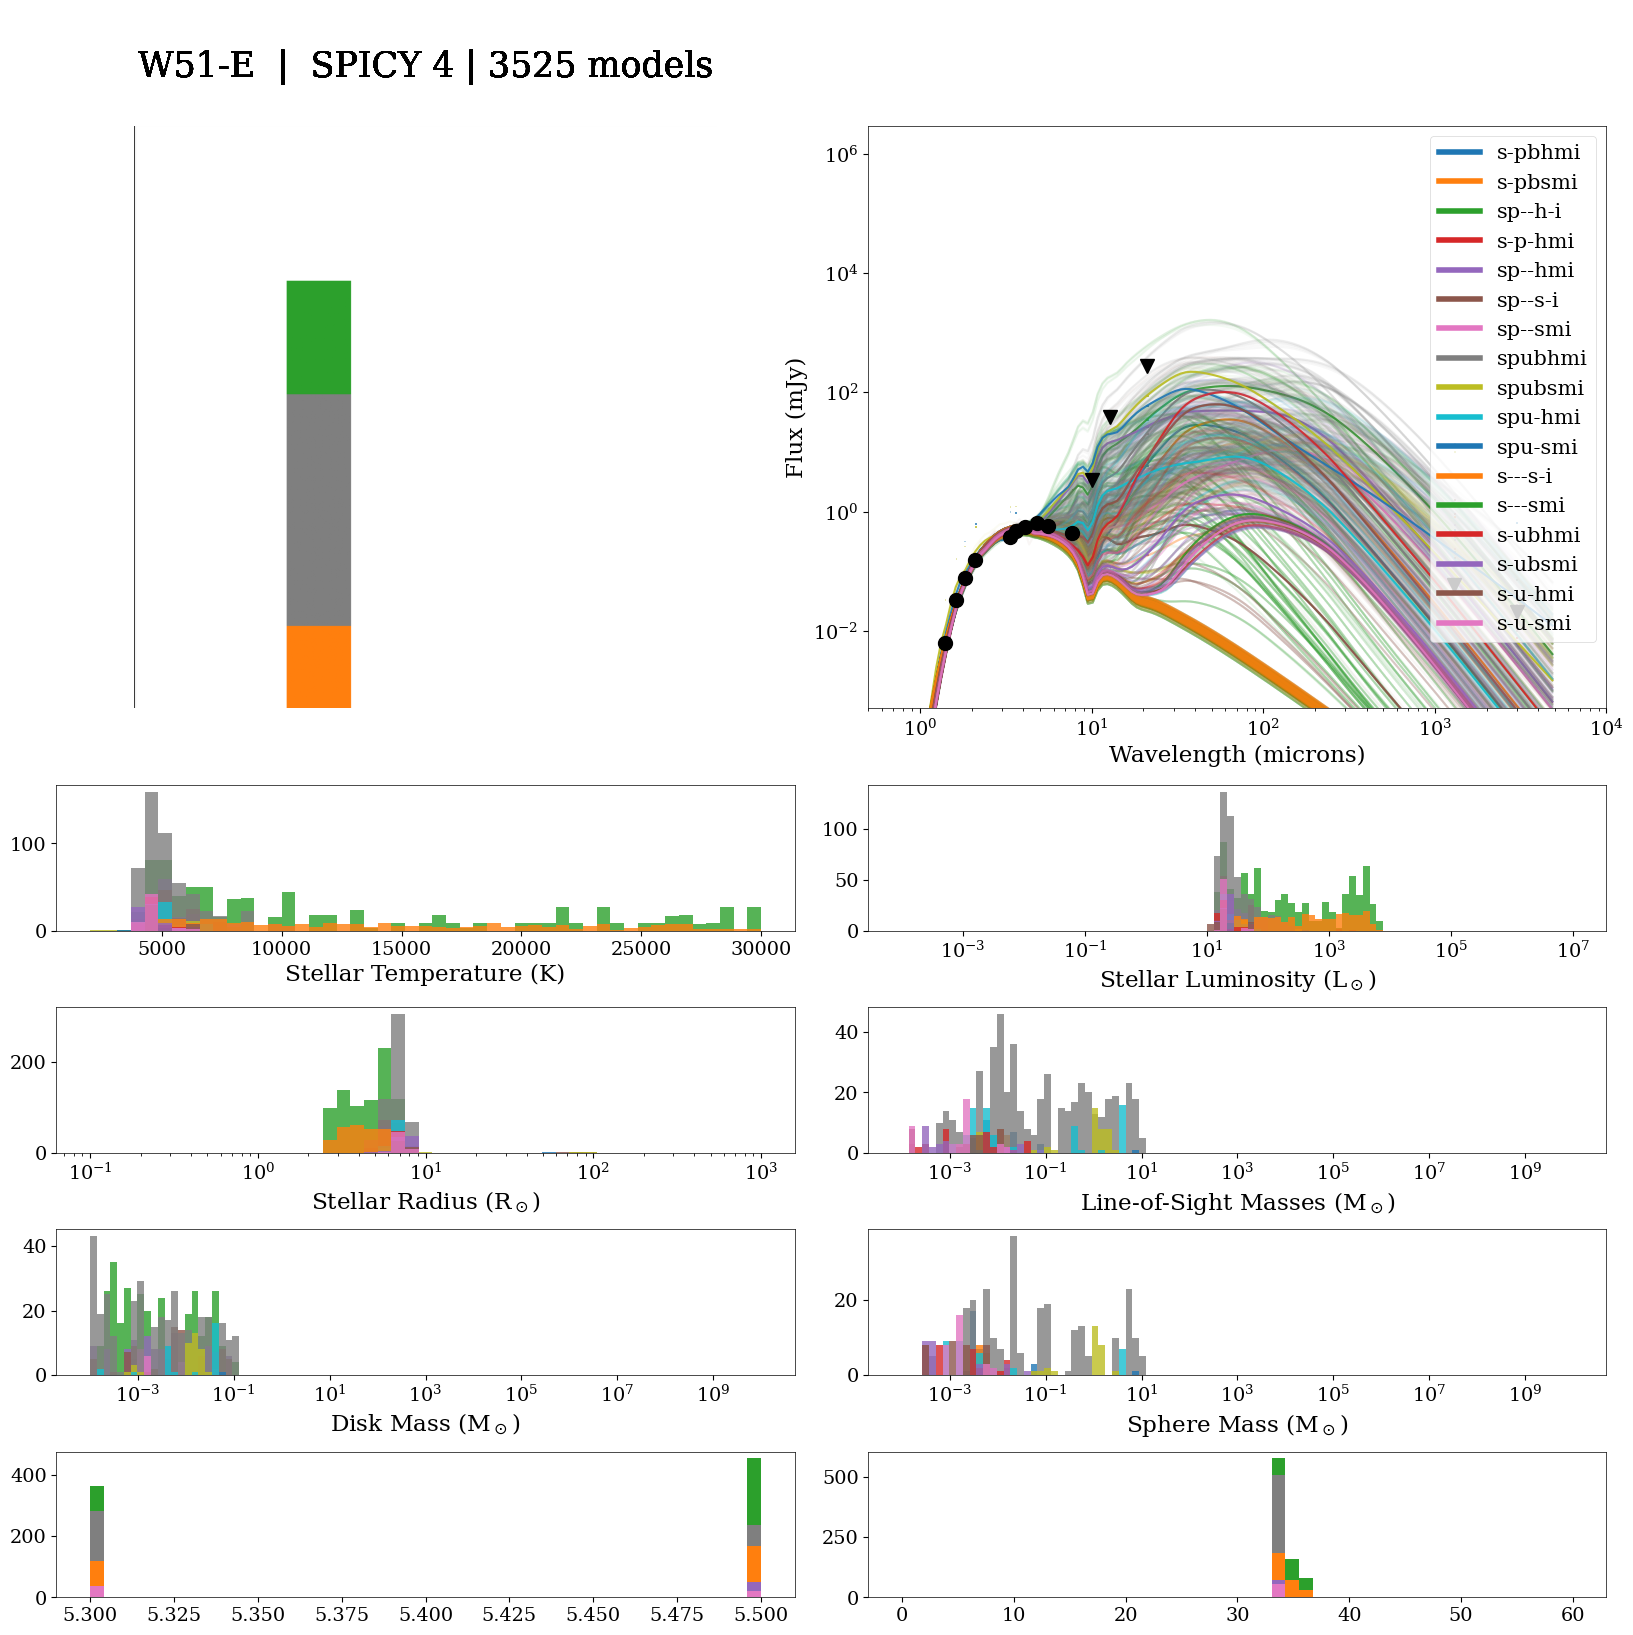

In [ ]:


from sedfitter.extinction import Extinction
from dust_extinction.shapes import P92

from astropy.wcs import WCS
from regions import Regions
from itertools import chain
from astropy import stats


w51e_b6_noise_region = '/orange/adamginsburg/w51/TaehwaYoo/regions/w51e_b6_std_sky_new.reg'
w51e_b3_noise_region = '/orange/adamginsburg/w51/TaehwaYoo/regions/w51e_b3_std_sky_new.reg'
w51n_b6_noise_region = '/orange/adamginsburg/w51/TaehwaYoo/regions/w51n_b6_std_sky_new.reg'
w51n_b3_noise_region = '/orange/adamginsburg/w51/TaehwaYoo/regions/w51n_b3_std_sky_new.reg'

read_w51e_b3_noise = Regions.read(w51e_b3_noise_region,format='ds9')
read_w51e_b6_noise = Regions.read(w51e_b6_noise_region,format='ds9')
read_w51n_b3_noise = Regions.read(w51n_b3_noise_region,format='ds9')
read_w51n_b6_noise = Regions.read(w51n_b6_noise_region,format='ds9')



def get_noise(fitsdata, noiseregion):
    
    image = fitsdata[0].data
    if len(image.shape)!=2:
        image = image[0][0] 
    hdrNB = fitsdata[0].header
    wcsNB = WCS(hdrNB,naxis=2)
    container = []
    for reg in noiseregion:
        pix_reg = reg.to_pixel(wcsNB)
        noisemask = pix_reg.to_mask()
        noiseim = noisemask.cutout(image)
        container.append(noiseim.flatten())
    noiseim = list(chain.from_iterable(container))
    std = stats.mad_std(noiseim,ignore_nan=True)

    return std
def add_alma(skycoord):
    from radio_beam import Beam
    from photutils.aperture import SkyEllipticalAperture
    from photutils.aperture import aperture_photometry
    from astropy.wcs import WCS

    w51e_b3_file = '/orange/adamginsburg/w51/TaehwaYoo/2017.1.00293.S_W51_B3_LB/may2021_successful_imaging/w51e2.spw0thru19.14500.robust0.thr0.075mJy.mfs.I.startmod.selfcal7.image.tt0.pbcor.fits'
    w51n_b3_file = '/orange/adamginsburg/w51/TaehwaYoo/2017.1.00293.S_W51_B3_LB/may2021_successful_imaging/w51n.spw0thru19.14500.robust0.thr0.075mJy.mfs.I.startmod.selfcal7.image.tt0.pbcor.fits'
    w51n_b6_file = '/orange/adamginsburg/w51/TaehwaYoo/w51n_b6_imaging_2025/w51n.spw0thru19.14500.robust0.thr0.1mJy.mfs.I.startmod.selfcal7.image.tt0.pbcor.fits'
    w51e_b6_file = '/orange/adamginsburg/w51/TaehwaYoo/w51e_b6_imaging_2025/w51e2.spw0thru19.14500.robust0.thr0.1mJy.mfs.I.startmod.selfcal7.image.tt0.pbcor.fits'

    w51e_alma_cat_file = '/orange/adamginsburg/w51/TaehwaYoo/dendro_w51e_master.fits'
    w51n_alma_cat_file = '/orange/adamginsburg/w51/TaehwaYoo/dendro_w51n_master.fits'
    w51e_b3_fits = fits.open(w51e_b3_file)
    w51n_b3_fits = fits.open(w51n_b3_file)
    w51n_b6_fits = fits.open(w51n_b6_file)
    w51e_b6_fits = fits.open(w51e_b6_file)
    
    w51e_b3_hdr = w51e_b3_fits[0].header
    w51n_b3_hdr = w51n_b3_fits[0].header
    w51n_b6_hdr = w51n_b6_fits[0].header
    w51e_b6_hdr = w51e_b6_fits[0].header

    w51e_b3_wcs = WCS(w51e_b3_hdr)
    w51n_b3_wcs = WCS(w51n_b3_hdr)
    w51n_b6_wcs = WCS(w51n_b6_hdr)
    w51e_b6_wcs = WCS(w51e_b6_hdr)
    
    w51e_b3_img = w51e_b3_fits[0].data[0][0]
    w51n_b3_img = w51n_b3_fits[0].data[0][0]
    w51n_b6_img = w51n_b6_fits[0].data[0][0]
    w51e_b6_img = w51e_b6_fits[0].data[0][0]

    w51e_alma_cat = Table.read(w51e_alma_cat_file)
    w51n_alma_cat = Table.read(w51n_alma_cat_file)

    # check whether skycoord is in the fov of the image
    fluxes = []
    flux_errs = []
    valids = []
    for alma_cat, b3_fits, b6_fits, b3_noise, b6_noise in zip([w51e_alma_cat, w51n_alma_cat], [w51e_b3_fits, w51n_b3_fits], [w51e_b6_fits, w51n_b6_fits], [read_w51e_b3_noise, read_w51n_b3_noise], [read_w51e_b6_noise, read_w51n_b6_noise]):
        print(alma_cat.colnames)
        for band in ['b6', 'b3']:
            skycoord_from_almacat = SkyCoord(ra=alma_cat[f'{band}_xsky']*u.deg, dec=alma_cat[f'{band}_ysky']*u.deg)
            separation = skycoord.separation(skycoord_from_almacat)
            ismatched = np.min(separation) < 0.1*u.arcsec


            if ismatched:
                flux = alma_cat[f'flux_{band}'][np.argmin(separation)].to(u.mJy).value
                fluxerr = alma_cat[f'fluxerr_{band}'][np.argmin(separation)].to(u.mJy).value
                print(f'matched with ALMA with flux: in {band} ', flux)

                valid = 1

            else:
                
                if band == 'b6':
                    b6_hdr = b6_fits[0].header
                    b6_img = b6_fits[0].data[0][0]
                    wcs_alma = WCS(b6_hdr, naxis=2)
                    img_alma = b6_img
                else:
                    b3_hdr = b3_fits[0].header
                    b3_img = b3_fits[0].data[0][0]
                    wcs_alma = WCS(b3_hdr, naxis=2)
                    img_alma = b3_img

                cel_wcs = wcs_alma.celestial
                pixcoord_alma = cel_wcs.world_to_pixel(skycoord)

                if (
                    pixcoord_alma[0] > 0 and pixcoord_alma[1] > 0
                    and pixcoord_alma[0] < img_alma.shape[1]
                    and pixcoord_alma[1] < img_alma.shape[0]
                ):
                    if band == 'b6':
                        beam_alma = Beam.from_fits_header(b6_hdr)
                        noiseregion = b6_noise
                        global_std = get_noise(b6_fits, noiseregion)

                    else:
                        beam_alma = Beam.from_fits_header(b3_hdr)
                        noiseregion = b3_noise
                        global_std = get_noise(b3_fits, noiseregion)
                    aperture = SkyEllipticalAperture(
                        positions=skycoord,
                        a=beam_alma.major,
                        b=beam_alma.minor,
                        theta=beam_alma.pa,
                    )
                    phot_table = aperture_photometry(img_alma, aperture,  wcs=wcs_alma)
                    print(phot_table.colnames)
                    if phot_table['aperture_sum'][0] < 0:
                        print('negative flux in aperture photometry, setting flux to NaN')

                        area_pix = (beam_alma.sr / wcs_alma.proj_plane_pixel_area()).to(u.dimensionless_unscaled).value
                        print('area_pix:', area_pix, 'global_std:', global_std)
                        flux = phot_table['aperture_sum'] * 1e3 - global_std * area_pix * 1e3
                        print('aperture_sum:', phot_table['aperture_sum'], 'flux:', flux)
                        valid=3
                        flux= global_std * 1e3
                        fluxerr=1
                    else:
                       
                        area_pix = (beam_alma.sr / wcs_alma.proj_plane_pixel_area()).to(u.dimensionless_unscaled).value
                        print('area_pix:', area_pix, 'global_std:', global_std)
                        flux = phot_table['aperture_sum'] * 1e3 - global_std * area_pix * 1e3
                        print('aperture_sum:', phot_table['aperture_sum'], 'flux:', flux)
                        fluxerr= global_std * np.sqrt(area_pix) * 1e3
                        valid = 3
                        if flux < 0:
                            print('negative flux after background subtraction, setting flux to NaN')
                            flux = global_std * 1e3
                            fluxerr = 1
                            valid = 3
                        print(f'inside fov of {band}, flux: {flux}')
                else:
                    flux = np.nan
                    fluxerr = np.nan
                    valid = 0
                    print(f'outside fov of {band}')
                    print('pixcoord_alma:', pixcoord_alma, 'img_alma.shape:', img_alma.shape)                
              
            if isinstance(flux, u.Quantity):
                flux = flux.value
            if isinstance(fluxerr, u.Quantity):
                fluxerr = fluxerr.value
            if isinstance(flux, np.ndarray):
                flux = flux.item()
            if isinstance(fluxerr, np.ndarray):
                fluxerr = fluxerr.item()
            fluxes.append(flux)
            flux_errs.append(fluxerr)
            valids.append(valid)
    b6_flux = [fluxes[0], fluxes[2]]
    b3_flux = [fluxes[1], fluxes[3]]   
    b3_valid = [valids[1], valids[3]]
    b6_valid = [valids[0], valids[2]]
    print('b3_flux:', b3_flux, 'b6_flux:', b6_flux, 'b3_valid:', b3_valid, 'b6_valid:', b6_valid)
    if np.all(np.isnan(b3_flux)):
        b3_flux_final = np.nan
        b3_fluxerr_final = np.nan
        b3_valid_final = 0
    else:
        b3_flux_final = np.nanmean(b3_flux)
        b3_fluxerr_final = np.sqrt(np.nansum(np.array([flux_errs[1], flux_errs[3]])**2)) / len([flux_errs[1], flux_errs[3]])
        b3_valid_final = 3
    if np.all(np.isnan(b6_flux)):
        b6_flux_final = np.nan
        b6_fluxerr_final = np.nan
        b6_valid_final = 0
    else:
        b6_flux_final = np.nanmean(b6_flux)
        b6_fluxerr_final = np.sqrt(np.nansum(np.array([flux_errs[0], flux_errs[2]])**2)) / len([flux_errs[0], flux_errs[2]])
        b6_valid_final = 3
    b3_valid_final = int(np.nanmax(b3_valid))
    b6_valid_final = int(np.nanmax(b6_valid))
    return b3_flux_final, b3_fluxerr_final, b6_flux_final, b6_fluxerr_final, b3_valid_final, b6_valid_final

def make_extinction():
    ext = P92()

    guyver2009_avtocol = (2.21e21 * u.cm**-2 * (1.34 * u.Da)).to(u.g / u.cm**2)
    ext_wav = np.sort((np.geomspace(0.001, 1000, 10000) / u.um).to(u.um, u.spectral()))
    ext_vals = ext(ext_wav)

    extinction = Extinction()
    extinction.wav = ext_wav
    extinction.chi = ext_vals / guyver2009_avtocol
    return extinction

extinction = make_extinction()


imgs ={filt: fits.getdata(image_filenames[filt], ext=('SCI', 1)) for filt in image_filenames.keys()} 
wcss = {filt: WCS(fits.getheader(image_filenames[filt], ext=('SCI', 1))) for filt in image_filenames.keys()}
max_fluxs = {filt: np.nanmax(catalog[f'flux_fit_{filt}']) for filt in image_filenames.keys()}
filter_names = list(mags.keys())


line_slope = (27 - 7) / (1.3 - 0.4)
line_intercept = 7 - line_slope * 0.4


upper_idx = np.where((f360-f480 > 0.15 + (1.5/6)*(f162-f210)) & (f162 - (line_slope * (f162 - f210) + line_intercept) < 0))[0]
lower_idx = np.where((f360-f480 <= 0.15 + (1.5/6)*(f162-f210)) & (f162 - (line_slope * (f162 - f210) + line_intercept) < 0))[0]


def get_valid(catalog_row, filters, imgs, wcss, max_fluxs, masks):
    valid = np.ones(len(filters), dtype=int)
    fluxarr = []

    for ii, filt in enumerate(filters):
        raw_flux = catalog_row[f'flux_fit_{filt}']
        

        flux = (raw_flux * u.MJy / u.sr * wcss[filt].proj_plane_pixel_area()).to(u.mJy).value

        if not np.ma.is_masked(raw_flux) and  np.isfinite(flux):
            print(f'flux is not masked for flux_fit_{filt}')
            valid[ii] = 1
            fluxarr.append(flux)
        else:
            print(f'flux is masked for flux_fit_{filt}')
            skycoord = catalog_row[f'skycoord_{filt}']
            pixcoord = wcss[filt].world_to_pixel(skycoord)
            central_pix = imgs[filt][int(pixcoord[1]), int(pixcoord[0])]

            if np.isnan(central_pix): #saturated
                valid[ii] = 2
                flux = max_fluxs[filt] * 1e3
            else: # nondetection
                valid[ii] = 3
                aperture = SkyCircularAperture(skycoord, r=fwhms[ii] * u.arcsec)
                aperture_area = (
                    fwhms[ii] * u.arcsec * fwhms[ii] * u.arcsec / wcss[filt].proj_plane_pixel_area()
                ).to_value(u.dimensionless_unscaled)
                annulus = SkyCircularAnnulus(
                    skycoord,
                    r_in=fwhms[ii] * 1.5 * u.arcsec,
                    r_out=fwhms[ii] * 2 * u.arcsec,
                )
                annulus_stats = ApertureStats(imgs[filt], annulus, wcs=wcss[filt], mask=masks[filt])
                bkg_mean = annulus_stats.mean
                phot_table = aperture_photometry(imgs[filt], aperture, wcs=wcss[filt])

                flux = (
                    (phot_table['aperture_sum'][0] - bkg_mean * aperture_area)
                    * u.MJy / u.sr * wcss[filt].proj_plane_pixel_area()
                ).to(u.mJy).value
                if flux < 0:
                    flux =0
                    valid[ii] = 0

                if np.isnan(flux):
                    valid[ii] = 2
                    flux = max_fluxs[filt] * 1e3

            fluxarr.append(flux)

    return valid.tolist(), np.array(fluxarr)

fwhms = []
fwhms_pix = []
wavelengths = []
for ii, filt in enumerate(filter_names):
    header = fits.getheader(image_filenames[filt], ext=('SCI', 1))
    if filt in ['f140m', 'f162m', 'f182m', 'f187n', 'f210m', 'f335m', 'f360m', 'f405n', 'f410m', 'f480m']:
        instrument_replacement = 'NIRCam'
    elif filt in ['f560w', 'f770w', 'f1000w', 'f1280w', 'f2100w']:
        instrument_replacement = 'MIRI'
    fwhm_tbl = Table.read('/orange/adamginsburg/w51/jwst/reduction/fwhm_table.ecsv')
    row = fwhm_tbl[fwhm_tbl['Filter'] == filt.upper()]
    fwhm = fwhm_arcsec = float(row['PSF FWHM (arcsec)'][0])
    pixel_scale = wcss[filt].proj_plane_pixel_scales()[0]
    fwhm_pix = fwhm_arcsec / pixel_scale.to_value(u.arcsec)
    #fwhm, fwhm_pix = get_fwhm(header, instrument_replacement=instrument_replacement)
    fwhms.append(fwhm_arcsec)
    fwhms_pix.append(fwhm_pix)
    wav = int(filt[1:-1])/100 #um
    wavelengths.append(wav)
fwhms = np.array(fwhms)
wavelengths = np.array(wavelengths)
masks = {}
for ii, filt in enumerate(filter_names):
    mask = np.isnan(imgs[filt])
    skycoord = catalog[f'skycoord_{filt}']
    pixcoord = wcss[filt].world_to_pixel(skycoord)

    mask[pixcoord[1].astype(int), pixcoord[0].astype(int)] = True
    R = int(np.ceil(fwhms_pix[ii]/2))
    yy, xx = np.ogrid[-R:R+1, -R:R+1]
    footprint = xx**2 + yy**2 <= R**2
    mask = binary_dilation(mask, structure=footprint)

    masks[filt] = mask



random20_upper_idx = np.random.choice(upper_idx, size=20, replace=False)
random20_lower_idx = np.random.choice(lower_idx, size=20, replace=False)

#best_geos_upper = []
model_ids_upper = {}
for ii, idx in enumerate(random20_upper_idx):
    if ii<=4:
        for filt in filter_names:
            print(f'filt: {filt}, flux_fit: {catalog[idx][f"flux_fit_{filt}"]}, flux_err: {catalog[idx][f"flux_err_{filt}"]}')
        #fluxarr = np.array([catalog[idx][f'flux_fit_{filt}'] for filt in filter_names])
        skycoord = catalog[idx]['skycoord_ref']
        print('skycoord:', skycoord)
        pixcoord_f560w = wcss['f560w'].world_to_pixel(skycoord)
        if pixcoord_f560w[0] < 0 or pixcoord_f560w[1] < 0 or pixcoord_f560w[0] >= imgs['f560w'].shape[1] or pixcoord_f560w[1] >= imgs['f560w'].shape[0]:
            filternames_use = ['f140m', 'f162m', 'f182m', 'f210m', 'f335m', 'f360m', 'f410m', 'f480m']
            imgs_use = {filt: imgs[filt] for filt in filternames_use}
            wcss_use = {filt: wcss[filt] for filt in filternames_use}
            max_fluxs_use = {filt: max_fluxs[filt] for filt in filternames_use}
            masks_use = {filt: masks[filt] for filt in filternames_use}
            wavelengths_use = [wavelengths[filter_names.index(filt)] for filt in filternames_use]
            fwhms_use = [fwhms[filter_names.index(filt)] for filt in filternames_use]
        else:
            filternames_use = filter_names
            imgs_use = imgs
            wcss_use = wcss
            max_fluxs_use = max_fluxs
            masks_use = masks
            wavelengths_use = wavelengths
            fwhms_use = fwhms
        # check the unit of flux_err in the catalog, it is in MJy/sr, so we need to convert it to mJy
        #print('wcss[filt].proj_plane_pixel_area():', wcss['f140m'].proj_plane_pixel_area())
        #print('catalog[idx][f"flux_err_{filt}"]:', catalog[idx][f'flux_err_f140m'])
        fluxerr = u.Quantity([(catalog[idx][f'flux_err_{filt}'] * u.MJy / u.sr * wcss[filt].proj_plane_pixel_area().to(u.sr)).to(u.mJy) for filt in filternames_use]) # Jy -> mJy
        

        valid, fluxarr = get_valid(catalog[idx], filternames_use, imgs_use, wcss_use, max_fluxs_use, masks_use)
        #print('fluxarr', fluxarr)
        print('valid before filtering:', valid)
        valid = np.asarray(valid, dtype=int)
        valid_idx = valid != 0

        fwhms_use = np.asarray(fwhms_use)[valid_idx]
        wavelengths_use = np.asarray(wavelengths_use)[valid_idx]
        fluxarr = np.asarray(fluxarr)[valid_idx]
        fluxerr = np.asarray(fluxerr)[valid_idx]
        valid = valid[valid_idx]
        valid = valid.tolist()
        print('valid after filtering:', valid)
        tab_upper = Table()
        tab_upper['aperture'] = fwhms_use
        tab_upper['wavelength'] = wavelengths_use
        tab_upper['flux'] = fluxarr
        tab_upper['eflux'] = fluxerr
        tab_upper['aperture'].unit = u.arcsec
        tab_upper['wavelength'].unit = u.um
        tab_upper['flux'].unit = u.mJy
        tab_upper['eflux'].unit = u.mJy
        b3_flux, b3_fluxerr, b6_flux, b6_fluxerr, b3_valid, b6_valid = add_alma(catalog[idx]['skycoord_ref'])
        print('b3_flux, b3_fluxerr, b6_flux, b6_fluxerr:', b3_flux, b3_fluxerr, b6_flux, b6_fluxerr)
        print('b3_valid', b3_valid)
        print('b6_valid', b6_valid)
        if not np.isnan(b6_flux):
            tab_upper.add_row([fwhms[-1], 1300, b6_flux, b6_fluxerr])
            valid.append(b6_valid)
        if not np.isnan(b3_flux):
            tab_upper.add_row([fwhms[-1], 3000, b3_flux, b3_fluxerr])   
            valid.append(b3_valid)
        print('flux', tab_upper['flux'])
        print('wavelength', tab_upper['wavelength'])
        print('valid', valid)
        print('av_estimates[idx]:', av_estimates[idx])


        #print('av_estimates[idx]:', av_estimates[idx])
        fits_dict = {geom:
            fit_a_source(data=tab_upper['flux'].quantity,
                error=tab_upper['eflux'].quantity,
                valid=valid, aperture_size=tab_upper['aperture'].quantity,
                filters=tab_upper['wavelength'].quantity,
                    av_range=[av_estimates[idx], 100],
                    distance_range=[5300,5500]*u.pc,
                        geometry=geom,
                        stash_to_mmap=True,
                        robitaille_modeldir='/blue/adamginsburg/richardson.t/research/flux/r+24_models-1.2',
                        extinction=extinction
                    )
            for geom in geometries}#['spubhmi']} #geometries}
        okgeo = []
        minchi2 = min([np.nanmin(fits_dict[geom].chi2) for geom in fits_dict])
        
        chi2limit = minchi2*3 if minchi2 > 3 else 9
        deltachi2limit = chi2limit - minchi2

        if np.isnan(minchi2):
            raise ValueError(f"minchi2 is NaN for source {idx}, check the input data and fitting process.")
        for geom in geometries:
          
            print(f"Delta-chi^2 = {deltachi2limit} for min chi2 = {minchi2}")
            if np.nanmin(fits_dict[geom].chi2) < deltachi2limit+minchi2:
                okgeo.append(geom)
        if len(okgeo)>0:
            for geom in okgeo:
                fitinfo = fits_dict[geom]

                selection = fitinfo.chi2 < chi2limit
                model_ids_upper[geom] = fitinfo.model_id[selection]
            plot_fit(fits=fits_dict, okgeo=okgeo, fieldid='W51-E', spicyid=ii, 
                chi2limit=minchi2*1.5, min_chi2=minchi2, show_all_models=True, extinction=extinction,
                loc_imagedir='/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/plots/seds_spicy', robitaille_modeldir='/blue/adamginsburg/richardson.t/research/flux/r+24_models-1.2',)

        """
        minminch2 = np.nanmin(minchi2s)
        # get geom in the minimum minchi2
        geom_best = list(fits_dict.keys())[np.argmin(minchi2s)]
        best_geos_upper.append(geom_best)
        fitinfo = fits_dict[geom_best]
        selection = np.argmin(fitinfo.chi2)
        #print('fitinfo.model_id[selection]:', fitinfo.model_id[selection])
        """


    
    
#cb26tbl = Table(rows=data,
#                names=['wavelength', 'flux', 'eflux', 'aperture'],
#                units=(u.um, u.mJy, u.mJy, u.arcsec)
#               )

In [4]:
dd

NameError: name 'dd' is not defined

In [ ]:

model_ids_lower = []
for ii, idx in enumerate(random20_lower_idx):
    if True:
        for filt in filter_names:
            print(f'filt: {filt}, flux_fit: {catalog[idx][f"flux_fit_{filt}"]}, flux_err: {catalog[idx][f"flux_err_{filt}"]}')
        #fluxarr = np.array([catalog[idx][f'flux_fit_{filt}'] for filt in filter_names])
        skycoord = catalog[idx]['skycoord_ref']
        pixcoord_f560w = wcss['f560w'].world_to_pixel(skycoord)
        if pixcoord_f560w[0] < 0 or pixcoord_f560w[1] < 0 or pixcoord_f560w[0] >= imgs['f560w'].shape[1] or pixcoord_f560w[1] >= imgs['f560w'].shape[0]:
            filternames_use = ['f140m', 'f162m', 'f182m', 'f210m', 'f335m', 'f360m', 'f410m', 'f480m']
            imgs_use = {filt: imgs[filt] for filt in filternames_use}
            wcss_use = {filt: wcss[filt] for filt in filternames_use}
            max_fluxs_use = {filt: max_fluxs[filt] for filt in filternames_use}
            masks_use = {filt: masks[filt] for filt in filternames_use}
            wavelengths_use = [wavelengths[filter_names.index(filt)] for filt in filternames_use]
            fwhms_use = [fwhms[filter_names.index(filt)] for filt in filternames_use]
        else:
            filternames_use = filter_names
            imgs_use = imgs
            wcss_use = wcss
            max_fluxs_use = max_fluxs
            masks_use = masks
            wavelengths_use = wavelengths
            fwhms_use = fwhms
        # check the unit of flux_err in the catalog, it is in MJy/sr, so we need to convert it to mJy
        #print('wcss[filt].proj_plane_pixel_area():', wcss['f140m'].proj_plane_pixel_area())
        #print('catalog[idx][f"flux_err_{filt}"]:', catalog[idx][f'flux_err_f140m'])
        fluxerr = u.Quantity([(catalog[idx][f'flux_err_{filt}'] * u.MJy / u.sr * wcss[filt].proj_plane_pixel_area().to(u.sr)).to(u.mJy) for filt in filternames_use]) # Jy -> mJy
        

        valid, fluxarr = get_valid(catalog[idx], filternames_use, imgs_use, wcss_use, max_fluxs_use, masks_use)
        #print('fluxarr', fluxarr)
        tab_upper = Table()
        tab_upper['aperture'] = fwhms_use
        tab_upper['wavelength'] = wavelengths_use
        tab_upper['flux'] = fluxarr
        tab_upper['eflux'] = fluxerr
        tab_upper['aperture'].unit = u.arcsec
        tab_upper['wavelength'].unit = u.um
        tab_upper['flux'].unit = u.mJy
        tab_upper['eflux'].unit = u.mJy
        #print('av_estimates[idx]:', av_estimates[idx])
        fits_dict = {geom:
            fit_a_source(data=tab_upper['flux'].quantity,
                error=tab_upper['eflux'].quantity,
                valid=valid, aperture_size=tab_upper['aperture'].quantity,
                filters=tab_upper['wavelength'].quantity,
                    av_range=[av_estimates[idx]-1, av_estimates[idx]+1],
                    distance_range=[5300,5500]*u.pc,
                        geometry=geom,
                        stash_to_mmap=True,
                        robitaille_modeldir='/blue/adamginsburg/richardson.t/research/flux/r+24_models-1.2',
                        extinction=extinction
                    )
            for geom in geometries}#['spubhmi']} #geometries}
        okgeo = []
        #for geom in geometries:
        minchi2s = []
        for geom in fits_dict:
            minchi2 =np.nanmin(fits_dict[geom].chi2)

            minchi2s.append(minchi2)
        minminch2 = np.nanmin(minchi2s)
        # get geom in the minimum minchi2
        geom_best = list(fits_dict.keys())[np.argmin(minchi2s)]
        best_geos_lower.append(geom_best)
        model_ids_lower.append(fitinfo.model_id[selection])


In [ ]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(121)
for geom, model_id in zip(best_geos_upper, model_ids_upper):
    fitinfo = fits_dict[geom]
    pars = Table.read(f'/blue/adamginsburg/richardson.t/research/flux/pars/{geom}_augmented.fits')
    selection = fitinfo.model_id == model_id
    data = pars[selection][0]
    print(data.colnames)
    try:
        disk_mass_upper = [data['disk.mass']]
        ax1.scatter(data['disk.mass'], data['envelope.mass'], label=f'geom: {geom}, model_id: {model_id}', alpha=0.5)
    except KeyError:
        print(f"KeyError for geom: {geom}, model_id: {model_id}")

ax2 = fig.add_subplot(122)

for geom, model_id in zip(best_geos_lower, model_ids_lower):
    fitinfo = fits_dict[geom]
    selection = fitinfo.model_id == model_id
    pars = Table.read(f'/blue/adamginsburg/richardson.t/research/flux/pars/{geom}_augmented.fits')
    data = pars[selection][0]
    try:
        disk_mass_lower = [data['disk.mass']]
        ax2.scatter(data['disk.mass'], data['envelope.mass'], label=f'geom: {geom}, model_id: {model_id}', alpha=0.5)

    except KeyError:
        print(f"KeyError for geom: {geom}, model_id: {model_id}")






In [ ]:
def map_to_class(class_indices):
    return -1*(class_indices-3)
import glob
from tqdm.auto import tqdm
all_gs = glob.glob('/blue/adamginsburg/richardson.t/research/flux/r+24_models-1.2/s*')
all_gs = [g.split('/')[-1] for g in all_gs if 'ipynb' not in g]

ap_ind = 3

class_dict = {}
classpoints = np.array([-1.6,-0.3,0.3,np.inf])
for g in tqdm(all_gs):
    geo = g.split('/')[-1]
    indices = Table.read(f'/blue/adamginsburg/richardson.t/research/flux/spectral_indices/{geo}.fits')

    obs_class = np.searchsorted(classpoints,indices['Spectral Index'][:,ap_ind],side='right')
    obs_class = map_to_class(np.array(obs_class))
    class_dict.update({geo:obs_class})
print(class_dict)
# assign class for the best model for each source
obs_classes_upper = []
obs_classes_lower = []
for geo, model_id in zip(best_geos_upper, model_ids_upper):
    obs_class = class_dict[geo][model_id]
    print(f'geom: {geo}, model_id: {model_id}, class: {obs_class}')
    obs_classes_upper.append(obs_class)
for geo, model_id in zip(best_geos_lower, model_ids_lower):
    obs_class = class_dict[geo][model_id]
    print(f'geom: {geo}, model_id: {model_id}, class: {obs_class}')
    obs_classes_lower.append(obs_class)


  

In [ ]:
def phys_stage(pars,g):
    stage = -1*np.ones(len(pars))
    hasDisk = 'disk.mass' in pars.keys()
    hasEnv = 'envelope.rho_0' in pars.keys()
    hasMedium = 'ambient.temperature' in pars.keys()

    geo = g.split('/')[-1]
    incs = geo_inc(geo)
    stats = Table.read(f'/blue/adamginsburg/richardson.t/research/flux/model_status/{geo}.fits')
    done_seds = np.ravel(stats['Exists'][:,None]*np.ones(incs)[None,:]).astype(int)
    exists = done_seds == 1
    if hasDisk or hasEnv:
        m_envs = np.nanmax(pars['Sphere Masses'][:,0],axis=-1)
        m_envs = np.ma.array(np.ravel(m_envs))
        if hasDisk:
            GDR = 100
            subs = m_envs - (GDR+1)*pars['disk.mass']
            #start stage 0; cool sources with massive envelopes                                                                                                                                                    
            stage0 = np.logical_and(subs > 0.1,pars['star.temperature'] < 3000)
            #cut down to models that actually have calculated sphere masses                                                                                                                                        
            stage0 = np.logical_and(stage0,~m_envs.mask)
            #cut further to models that exist                                                                                                                                                                      
            stage0 = np.logical_and(stage0,exists)
            stage[stage0] = 0
            #start stage I; prestellar sources with massive envelopes                                                                                                                                              
            stage1 = np.logical_and(subs > 0.1,pars['star.temperature'] > 3000)
            #cut to models with calculated sphere masses                                                                                                                                                           
            stage1 = np.logical_and(stage1,~m_envs.mask)
            #cut to existing models                                                                                                                                                                                
            stage1 = np.logical_and(stage1,exists)
            stage[stage1] = 1
            #start stage II; sources with disks                                                                                                                                                                    
            #including models w/o calculated sphere masses to catch disks within smallest aperture                                                                                                                 
            stage2 = np.logical_or(subs <= 0.1,m_envs.mask)
            #then cut models that don't exist                                                                                                                                                                      
            stage2 = np.logical_and(stage2,exists)
            stage[stage2] = 2
        else:
            #same deal as above, but no stage II                                                                                                                                                                   
            stage0 = np.logical_and(m_envs > 0.1,pars['star.temperature'] < 3000)
            stage0 = np.logical_and(stage0,~m_envs.mask)
            stage0 = np.logical_and(stage0,exists)
            stage[stage0] = 0
            stage1 = np.logical_and(m_envs > 0.1,pars['star.temperature'] > 3000)
            stage1 = np.logical_and(stage1,~m_envs.mask)
            stage1 = np.logical_and(stage1,exists)
            stage[stage1] = 1
        if hasMedium:
            #find models where there is no density above ambient medium (i.e. hidden s---smi)                                                                                                                      
            stage3 = np.logical_and(stats['Exists'] == 1,stats['Has Structure'] == 0)
        else:
            #find models with no density structures (i.e. hidden s---s-i)                                                                                                                                          
            stage3 = np.logical_and(stats['Exists'] == 1,stats['Density OK'] == 0)
        stage3 = np.ravel(stage3[:,None]*np.ones(incs)[None,:]).astype(int)
        stage[np.where(stage3)] = 3
    else:
        stage[exists] = 3
    return stage

physical_stages_upper = []
for geom, model_id in zip(best_geos_upper, model_ids_upper):
    fitinfo = fits_dict[geom]
    selection = fitinfo.model_id == model_id
    pars = Table.read(f'/blue/adamginsburg/richardson.t/research/flux/pars/{geom}_augmented.fits')

    # = fitinfo.parameters[selection][0]
    stage = phys_stage(pars, geom)
    physical_stages_upper.append(stage)
physical_stages_lower = []
for geom, model_id in zip(best_geos_lower, model_ids_lower):
    fitinfo = fits_dict[geom]
    selection = fitinfo.model_id == model_id
    pars = fitinfo.parameters[selection][0]
    stage = phys_stage(pars, geom)
    physical_stages_lower.append(stage)


In [ ]:
# plot histogram of spectral class for upper and lower sources
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.hist(obs_classes_upper, bins=np.arange(0, 4)-0.5, alpha=0.5, label='Upper Sources')
plt.xticks([0,1,2,3], ['Class I', 'Class II', 'Flat', 'Class III'])
plt.xlabel('Spectral Class')
plt.ylabel('Number of Sources')
plt.subplot(1,2,2)
plt.hist(obs_classes_lower, bins=np.arange(0, 4)-0.5, alpha=0.5, label='Lower Sources')
plt.xticks([0,1,2,3], ['Class I', 'Class II', 'Flat', 'Class III'])
plt.xlabel('Spectral Class')
plt.ylabel('Number of Sources')

In [ ]:
# plot histogram of physcial stages 
plt.figure(figsize=(10,5))
plt.hist(obs_classes_upper, bins=np.arange(0, 4)-0.5, alpha=0.5, label='Upper Sources') 
plt.xticks([0,1,2,3], ['Class 0', 'Class I', 'Class II', 'Class III'])
plt.xlabel('Spectral Class')
plt.ylabel('Number of Sources')

In [ ]:
import plot_SED

for ii, idx in enumerate(upper_idx):
    if ii<=3:
        skycoord = catalog[idx]['skycoord_ref']
        plot_SED.plot_SED(skycoord, ii, SEDsavedir=None, show=True)
